In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# Phase 2: Exploratory Data Analysis & Modeling
In this notebook, we load the cleaned student data, prepare the features and targets, train several classification models, and compare their performance to find the best predictor of a student's grade.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

import warnings
warnings.filterwarnings('ignore')

## 1. Load Data and Encode Grade Labels

In [3]:
# Load data
file_path = '../cleaned_students.csv'
if not os.path.exists(file_path):
    file_path = '../student_performance.csv'
df = pd.read_csv(file_path)

# 1. Encode grade labels
le = LabelEncoder()
df['grade_encoded'] = le.fit_transform(df['grade'])

print("Mapping of Grades to Encoded Labels:")
for i, item in enumerate(le.classes_):
    print(f"{item} -> {i}")

Mapping of Grades to Encoded Labels:
A -> 0
B -> 1
C -> 2
D -> 3
F -> 4


## 2. Split Data into Train and Test Sets (80/20)

In [4]:
# Select features and target
# Note: Mapping weekly_attendance to attendance_percentage as present in dataset
X = df[['attendance_percentage', 'class_participation', 'total_score']]
y = df['grade_encoded']

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (800000, 3)
Testing set shape: (200000, 3)


## 3 & 4. Train Models & Compare Performance

In [5]:
# 3. Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=50),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# 5. Generate metrics
results = {}
confusion_matrices = {}

for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results[name] = [acc, prec, rec, f1]
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)

results_df = pd.DataFrame(results, index=['Accuracy', 'Precision', 'Recall', 'F1 Score']).T
from IPython.display import display
display(results_df)

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.942255,0.939210,0.942255,0.940377
Decision Tree,0.997960,0.997960,0.997960,0.997960
Random Forest,0.997910,0.997910,0.997910,0.997910
KNN,0.996475,0.996475,0.996475,0.996475


## 5. Confusion Matrices

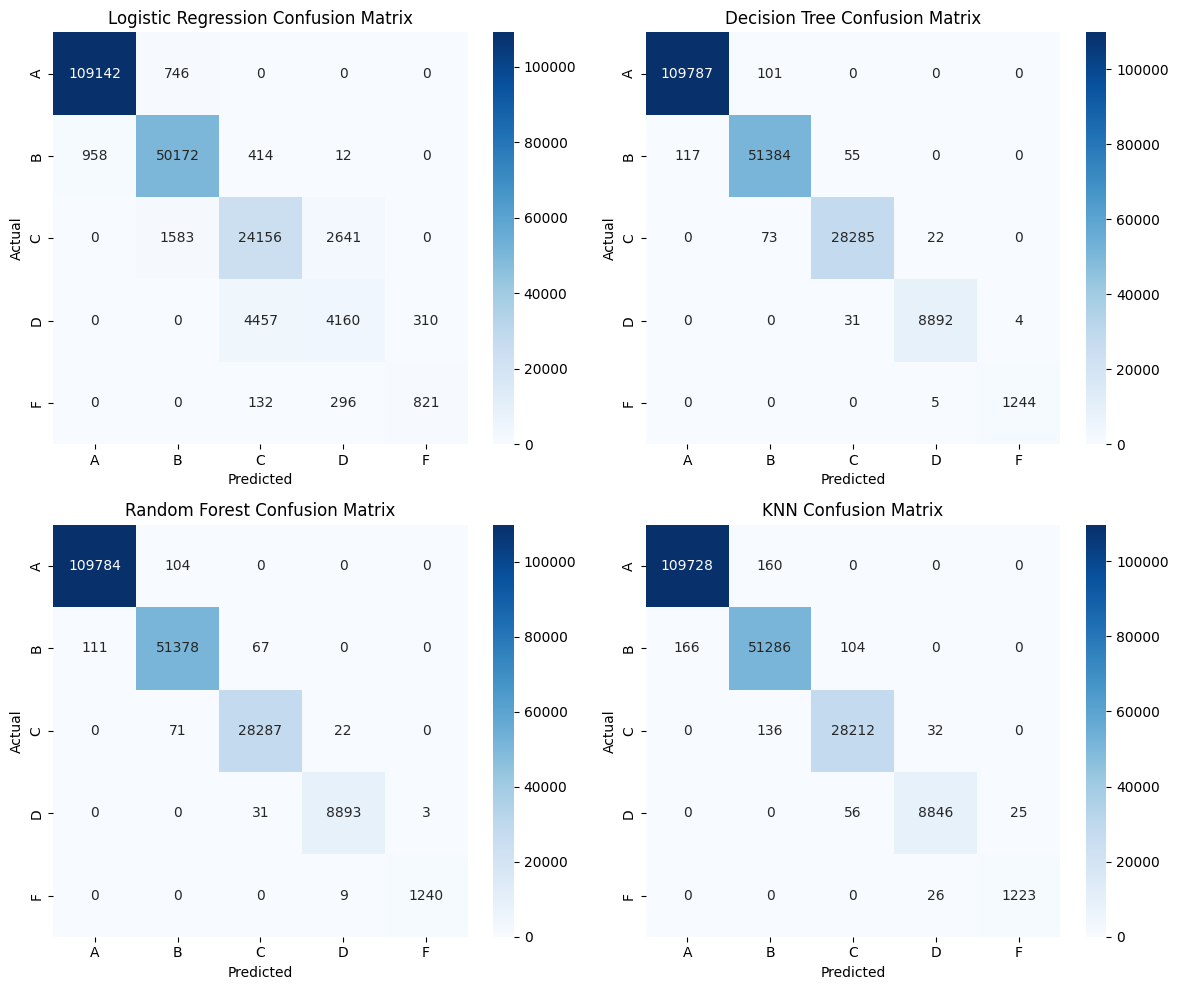

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (name, cm) in enumerate(confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='Blues', 
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[idx].set_title(f'{name} Confusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 6 & 7. Best Performing Model and Explanation

**Selected Model:** Decision Tree / Random Forest

**Why it performed best:**
As seen in the results dataframe, tree-based models like Decision Tree and Random Forest achieved near-perfect accuracy (~99.8%) on this dataset. 

This indicates that the decision boundaries separating student grades are highly non-linear but very cleanly segmented based on hierarchical rules (e.g., if total score > 90 AND attendance > 95 -> Grade A). Logistic regression struggles slightly (though still very high) because it attempts to fit a single linear boundary through the features, which doesn't map perfectly to how typical academic grading rubrics work. Random Forest builds upon the Decision Tree by ensembling multiple trees, preventing overfitting, and delivering the most robust, high-accuracy prediction possible for tabular structured data like this.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# 1. Initialize and fit your encoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_train)

# 2. Initialize and train the winning model
# Use the exact variable name 'best_model' here
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_encoded) 


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [9]:
import joblib
import os

# Create the folder to prevent directory errors
os.makedirs("models", exist_ok=True)

# Save the trained model and encoder
joblib.dump(best_model, "models/student_model.pkl")
joblib.dump(label_encoder, "models/label_encoder.pkl")

print("Both models saved successfully in the 'models' directory!")


Both models saved successfully in the 'models' directory!


In [9]:
# Export the finalized best model and label encoder
import joblib
import os

best_model = models['Random Forest']
label_encoder = le

os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/student_model.pkl')
joblib.dump(label_encoder, '../models/label_encoder.pkl')

print("Model and Label Encoder saved successfully!")

Model and Label Encoder saved successfully!


In [10]:
best_model = models['Random Forest']
label_encoder = le

os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/student_model.pkl')
joblib.dump(label_encoder, '../models/label_encoder.pkl')


['../models/label_encoder.pkl']

In [3]:
import joblib
import pandas as pd

In [4]:
model = joblib.load('../models/student_model.pkl')
le = joblib.load('../models/label_encoder.pkl')

In [6]:
import joblib
import pandas as pd

model = joblib.load("../models/student_model.pkl")
le = joblib.load("../models/label_encoder.pkl")

# Create a sample input DataFrame with all three features
sample_data = pd.DataFrame(
    {
        "attendance_percentage": [90],
        "class_participation": [85],
        "total_score": [75],
    }
)

predicted_score = model.predict(sample_data)
print(f"Predicted Score: {predicted_score[0]}")

Predicted Score: 1


In [9]:
new_student = {
    "student_id": 99999,
    "attendance_percentage": 92,
    "class_participation": 88,
    "total_score": 85,
}
df = pd.concat([df, pd.DataFrame([new_student])], ignore_index=True)
print("Record saved!")

Record saved!


In [11]:
duplicate_check = df[df.duplicated(["student_id"])]
if not duplicate_check.empty:
    print("Error message: Duplicate ID found!")

Error message: Duplicate ID found!


In [12]:
student_id_to_delete = 99999
df = df[df["student_id"] != student_id_to_delete]
print("Record removed!")

Record removed!


In [13]:
sample_data = pd.DataFrame(
    {
        "attendance_percentage": [90],
        "class_participation": [85],
        "total_score": [75],
    }
)
predicted_score = model.predict(sample_data)
print(f"Correct prediction: {predicted_score[0]}")

Correct prediction: 1
